# DOM 성능 저하 원인 진단 — 회전 스윕 + 방위각×편파 표

## 목적
DOM 48개(방위각 12 × 편파 4) 중 **첫 파일(0azi)만 잘 되고 나머지는 무너지는** 현상의
원인을 두 가설로 나눠 검증한다.

- **가설 1 (방위각/회전):** 현재 보정은 0°에서만 자명하게 맞고, 비0° 장면엔 올바른 회전이
  안 들어간다. → **Test A: 한 비0° 장면에서 회전각을 0~360° 촘촘히 스윕**해
  recall이 특정 각도에서 살아나는지 본다. 살아나면 "회전값 문제"(고칠 수 있음).
- **가설 2 (편파):** cross-pol(HV/VH)이 co-pol과 신호가 달라 회전과 무관하게 깎인다.
  → **Test B: 48개를 (방위각 × 편파) 표로** 펼쳐 badness가 어느 축을 따라가는지 본다.

## 사용 모델/설정 (기존 파이프라인과 동일)
- 탐지기 `checkpoints/yolo_detector.pt` (conf 0.5, SAHI 타일 256/overlap 0.25/100px 필터)
- 분류기 `checkpoints/resnet18_soc50_final.pth` (50종)

## 사전 준비 (드라이브 `MyDrive/ATRNet-STAR/`)
- `dom_scenes.tar` — DOM 풀씬 48장 + 정답 xml(Annotation)
- `checkpoints/yolo_detector.pt`, `checkpoints/resnet18_soc50_final.pth`
- `results/resnet18_soc50.json` (클래스 순서)
- 런타임 → **T4 GPU**

## 1. 환경 준비

In [ ]:
import torch
from google.colab import drive
drive.mount('/content/drive')

!pip -q install ultralytics sahi

SAVE_DIR = "/content/drive/MyDrive/ATRNet-STAR"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "/", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.1 MB/s eta 0:00:00
device: cuda / Tesla T4


## 2. DOM 데이터 준비 + 48개 메타(방위각/편파) 파싱
`dom_scenes.tar`를 풀고, 파일명·폴더명에서 방위각·편파·밴드를 뽑아 목록을 만든다.

In [ ]:
import os, glob, re

if not os.path.exists("/content/raw_scenes"):
    !cp "{SAVE_DIR}/dom_scenes.tar" /content/dom_scenes.tar
    !tar -xf /content/dom_scenes.tar -C /content/ && rm /content/dom_scenes.tar

dom_tifs = sorted(glob.glob("/content/raw_scenes/**/DOM*.tif", recursive=True))

POLMAP = {"H1H1": "HH", "H1V1": "HV", "V1H1": "VH", "V1V1": "VV"}
def scene_meta(path):
    folder = path.split("/")[-2]                     # 예: 30deg_150azi_ID9
    fname  = os.path.basename(path)                  # 예: DOM_KuSAR_H1H1_STR1_azbias1024.tif
    azi = int(re.search(r"(\d+)azi", folder).group(1))
    dep = int(re.search(r"(\d+)deg", folder).group(1))
    parts = fname.split("_")
    band = parts[1].replace("SAR", "")
    pol  = POLMAP.get(parts[2], parts[2])
    return dict(path=path, folder=folder, azi=azi, dep=dep, band=band, pol=pol)

meta = [scene_meta(p) for p in dom_tifs]
print(f"DOM 장면 {len(dom_tifs)}장 (방위각 {sorted(set(m['azi'] for m in meta))})")
print(f"편파 {sorted(set(m['pol'] for m in meta))} / 밴드 {sorted(set(m['band'] for m in meta))}\n")

print(f"{'idx':>3} | {'azi':>4} | {'pol':>3} | folder")
print("-" * 45)
for i, m in enumerate(meta):
    print(f"{i:>3} | {m['azi']:>4} | {m['pol']:>3} | {m['folder']}")

DOM 장면 48장 (방위각 [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330])
편파 ['HH', 'HV', 'VH', 'VV'] / 밴드 ['Ku']

idx |  azi | pol | folder
---------------------------------------------
  0 |    0 |  HH | 30deg_0azi_ID1
  1 |    0 |  HV | 30deg_0azi_ID1
  2 |    0 |  VH | 30deg_0azi_ID1
  3 |    0 |  VV | 30deg_0azi_ID1
  4 |  120 |  HH | 30deg_120azi_ID3
  5 |  120 |  HV | 30deg_120azi_ID3
  6 |  120 |  VH | 30deg_120azi_ID3
  7 |  120 |  VV | 30deg_120azi_ID3
  8 |  150 |  HH | 30deg_150azi_ID9
  9 |  150 |  HV | 30deg_150azi_ID9
 10 |  150 |  VH | 30deg_150azi_ID9
 11 |  150 |  VV | 30deg_150azi_ID9
 12 |  180 |  HH | 30deg_180azi_ID4
 13 |  180 |  HV | 30deg_180azi_ID4
 14 |  180 |  VH | 30deg_180azi_ID4
 15 |  180 |  VV | 30deg_180azi_ID4
 16 |  210 |  HH | 30deg_210azi_ID10
 17 |  210 |  HV | 30deg_210azi_ID10
 18 |  210 |  VH | 30deg_210azi_ID10
 19 |  210 |  VV | 30deg_210azi_ID10
 20 |  240 |  HH | 30deg_240azi_ID5
 21 |  240 |  HV | 30deg_240azi_ID5
 22 |  240 |  VH | 30deg_2

## 3. 모델 로드 (탐지기 + ResNet18 분류기)

In [ ]:
import json
import torch.nn as nn
from torchvision.models import resnet18
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

det_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=f"{SAVE_DIR}/checkpoints/yolo_detector.pt",
    confidence_threshold=0.5,
    device="cuda:0" if torch.cuda.is_available() else "cpu",
    image_size=256,
)

try:
    with open(f"{SAVE_DIR}/results/resnet18_soc50.json") as f:
        CLASS_NAMES = json.load(f)["classes"]
    print("클래스 순서: results/resnet18_soc50.json")
except FileNotFoundError:
    if not os.path.exists("/content/SOC_50classes"):
        !cp "{SAVE_DIR}/soc50.tar" /content/soc50.tar
        !tar -xf /content/soc50.tar -C /content/ && rm /content/soc50.tar
    CLASS_NAMES = sorted(os.listdir("/content/SOC_50classes/test"))
    print("클래스 순서: soc50.tar/test")
NUM_CLASSES = len(CLASS_NAMES)

classifier = resnet18()
classifier.fc = nn.Linear(classifier.fc.in_features, NUM_CLASSES)
classifier.load_state_dict(torch.load(f"{SAVE_DIR}/checkpoints/resnet18_soc50_final.pth",
                                      map_location=device))
classifier = classifier.to(device).eval()
print("분류기 로드 완료 / 클래스 수:", NUM_CLASSES)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
클래스 순서: results/resnet18_soc50.json
분류기 로드 완료 / 클래스 수: 50


## 4. 공통 함수 — 임의각 회전 + 탐지 + 분류 + 평가
- `rotate_scene(arr, angle)`: cv2로 임의 각도 회전(캔버스 확장). 변환행렬 M도 반환
  → 회전 프레임의 박스를 원본 좌표로 되돌릴 때 사용
- `eval_at_angle`: 장면을 angle만큼 회전 → 탐지 → GT 매칭으로 recall, 그리고
  매칭된 표적의 분류 정확도까지 한 번에 계산 (분류 크롭은 회전 프레임에서)

In [ ]:
import numpy as np, cv2
from PIL import Image
import torchvision.transforms as T
Image.MAX_IMAGE_PIXELS = None

def load_dom_rgb(path):
    arr = np.array(Image.open(path))
    if arr.dtype != np.uint8:                          # 혹시 float면 99퍼센타일 정규화
        a = arr.astype(np.float32); p = np.percentile(a[a > 0], 99)
        arr = np.clip(a / (p + 1e-9) * 255, 0, 255).astype(np.uint8)
    if arr.ndim == 2:
        arr = np.stack([arr] * 3, axis=-1)
    return arr

cls_transform = T.Compose([
    T.Resize((128, 128)), T.Grayscale(num_output_channels=3), T.ToTensor(),
])
def classify_box(scene_rgb, box, win=128):
    H, W = scene_rgb.shape[:2]
    x1, y1, x2, y2 = box
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    left = int(min(max(cx - win / 2, 0), max(W - win, 0)))
    top  = int(min(max(cy - win / 2, 0), max(H - win, 0)))
    chip = Image.fromarray(scene_rgb[top:top + win, left:left + win])
    x = cls_transform(chip).unsqueeze(0).to(device)
    with torch.no_grad():
        prob = torch.softmax(classifier(x), dim=1)[0]
    idx = int(prob.argmax())
    return CLASS_NAMES[idx], float(prob[idx])

def rotate_scene(arr, angle):
    # angle도(deg) CCW 회전, 캔버스 확장. M: 원본(x,y)->회전(x',y') (2x3)
    H, W = arr.shape[:2]
    M = cv2.getRotationMatrix2D((W / 2, H / 2), angle, 1.0)
    cos, sin = abs(M[0, 0]), abs(M[0, 1])
    Wn, Hn = int(H * sin + W * cos), int(H * cos + W * sin)
    M[0, 2] += Wn / 2 - W / 2
    M[1, 2] += Hn / 2 - H / 2
    rot = cv2.warpAffine(arr, M, (Wn, Hn))
    return rot, M

def invert_M(M):
    A = np.vstack([M, [0, 0, 1]])
    return np.linalg.inv(A)[:2]

def map_box(M, b):
    pts = [(b[0], b[1]), (b[2], b[1]), (b[2], b[3]), (b[0], b[3])]
    xs = [M[0, 0]*x + M[0, 1]*y + M[0, 2] for x, y in pts]
    ys = [M[1, 0]*x + M[1, 1]*y + M[1, 2] for x, y in pts]
    return [min(xs), min(ys), max(xs), max(ys)]

def iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    return inter / ((a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter + 1e-9)

def detect_on(arr_rgb, conf=0.5, smax=100):
    det_model.confidence_threshold = conf
    r = get_sliced_prediction(arr_rgb, det_model,
        slice_height=256, slice_width=256,
        overlap_height_ratio=0.25, overlap_width_ratio=0.25,
        perform_standard_pred=False, verbose=0)
    return [[p.bbox.minx, p.bbox.miny, p.bbox.maxx, p.bbox.maxy]
            for p in r.object_prediction_list
            if (p.bbox.maxx-p.bbox.minx) < smax and (p.bbox.maxy-p.bbox.miny) < smax]

def load_gt(dom_path):
    ann = dom_path.replace("/Result/", "/Annotation/").replace(".tif", ".xml")
    import xml.etree.ElementTree as ET
    gt = []
    if os.path.exists(ann):
        for obj in ET.parse(ann).getroot().findall("object"):
            bb = obj.find("bndbox")
            box = [float(bb.find(t).text) for t in ["xmin", "ymin", "xmax", "ymax"]]
            gt.append((box, obj.find("type").text))
    return gt

def eval_at_angle(scene_rgb, gt, angle, conf=0.5):
    # 반환: recall, 분류정확도(탐지성공분), 탐지박스수
    if angle % 360 == 0:
        rot, det_rot = scene_rgb, None
        det_rot = detect_on(scene_rgb, conf)
        det_orig = det_rot
    else:
        rot, M = rotate_scene(scene_rgb, angle)
        det_rot = detect_on(rot, conf)
        Minv = invert_M(M)
        det_orig = [map_box(Minv, b) for b in det_rot]
    n_det = n_cls = 0
    for gbox, gtype in gt:
        best_i, best_iou = -1, 0.3
        for i, d in enumerate(det_orig):
            v = iou(gbox, d)
            if v >= best_iou:
                best_iou, best_i = v, i
        if best_i >= 0:
            n_det += 1
            vtype, _ = classify_box(rot, det_rot[best_i])   # 분류는 회전 프레임 크롭
            if vtype == gtype:
                n_cls += 1
    N = max(len(gt), 1)
    return n_det / N, (n_cls / n_det if n_det else 0.0), len(det_orig)

## 5. Test A — 한 비0° 장면에서 회전각 정밀 스윕  ← 가설 1 검증
방위각 ≠ 0인 장면 하나를 골라 0~360°를 `STEP` 간격으로 회전하며 recall·분류를 측정한다.

- **특정 각도에서 recall이 확 살아나면** → "회전값/부호 문제"가 맞고, 그 각도가 정답.
  (그 각도가 장면의 방위각과 다르면, 현재 보정의 각도 매핑이 틀렸다는 직접 증거)
- **어느 각도에서도 안 살아나면** → 회전이 아니라 더 깊은 문제(편파/스케일/밴드).

장면 [4] 30deg_120azi_ID3 / pol=HH / 방위각=120° / GT 40대
크기(H,W)=(4337, 4036)

angle |  recall |    cls | box
    0 |   22.5% |  44.4% | 16
   30 |   47.5% |  15.8% | 63
   60 |   52.5% |  38.1% | 66
   90 |   70.0% |  46.4% | 33
  120 |   22.5% |  55.6% | 64  <-- 방위각
  150 |   25.0% |  70.0% | 59
  180 |   30.0% |  33.3% | 25
  210 |   30.0% |  16.7% | 64
  240 |   35.0% |   7.1% | 60
  270 |   37.5% |  26.7% | 19
  300 |   17.5% |  28.6% | 39
  330 |   30.0% |   8.3% | 55

최고 recall 각도: 90° (recall 70.0%, 분류 46.4%)  |  장면 방위각: 120°


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50965 (\N{HANGUL SYLLABLE WIB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

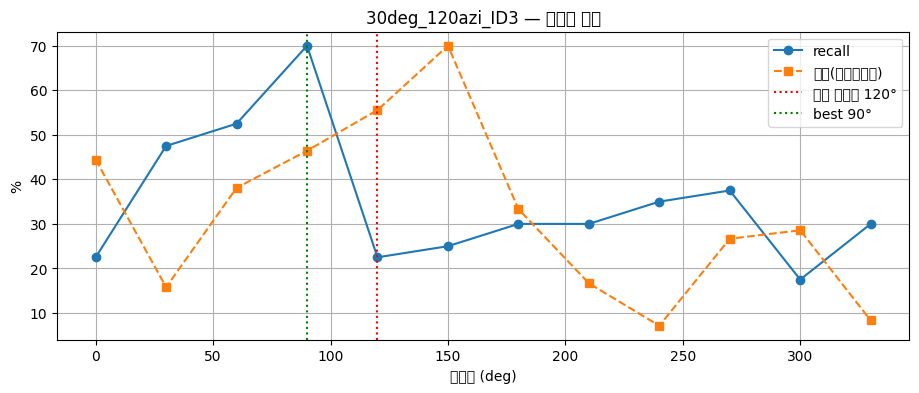

In [ ]:
import matplotlib.pyplot as plt

# ▼ 방위각이 0이 아닌 장면 idx 하나 선택 (셀 2 표 참고). 예: 150azi HH
SCENE_IDX = next(i for i, m in enumerate(meta) if m["azi"] != 0)
STEP = 30          # 각도 간격(도). 더 촘촘히 보려면 15 또는 10
# ─────────────────────────────────────────────

m = meta[SCENE_IDX]
scene_rgb = load_dom_rgb(m["path"])
gt = load_gt(m["path"])
print(f"장면 [{SCENE_IDX}] {m['folder']} / pol={m['pol']} / 방위각={m['azi']}° / GT {len(gt)}대")
print(f"크기(H,W)={scene_rgb.shape[:2]}\n")

angles = list(range(0, 360, STEP))
recs, clss, nbox = [], [], []
print(f"{'angle':>5} | {'recall':>7} | {'cls':>6} | box")
for a in angles:
    r, c, nb = eval_at_angle(scene_rgb, gt, a)
    recs.append(r); clss.append(c); nbox.append(nb)
    mark = "  <-- 방위각" if a == m["azi"] else ""
    print(f"{a:>5} | {r*100:>6.1f}% | {c*100:>5.1f}% | {nb}{mark}")

best_i = int(np.argmax(recs))
print(f"\n최고 recall 각도: {angles[best_i]}° (recall {recs[best_i]*100:.1f}%, "
      f"분류 {clss[best_i]*100:.1f}%)  |  장면 방위각: {m['azi']}°")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(angles, [r*100 for r in recs], "o-", label="recall")
ax.plot(angles, [c*100 for c in clss], "s--", label="분류(탐지성공분)")
ax.axvline(m["azi"], color="red", ls=":", label=f"장면 방위각 {m['azi']}°")
ax.axvline(angles[best_i], color="green", ls=":", label=f"best {angles[best_i]}°")
ax.set_xlabel("회전각 (deg)"); ax.set_ylabel("%"); ax.set_title(f"{m['folder']} — 회전각 스윕")
ax.legend(); ax.grid(True); plt.show()

### Test A 해석
- best 각도 ≈ 방위각(또는 -방위각) 이면 → 보정 방향은 맞는데 부호/자동판정이 불안정했던 것
- best 각도 = 방위각 ± 90°(또는 일정 오프셋) 이면 → 각도 매핑 자체가 틀린 것 (오프셋 교정으로 해결)
- best에서도 recall이 낮으면(예: <50%) → 회전만으로 안 됨 → 가설 2(편파 등)로 무게 이동

 azi |  best각 | best recall
   0 |     0° |      95.0%
  30 |     0° |      92.5%
  60 |    90° |      82.5%
  90 |    90° |      95.0%
 120 |    90° |      70.0%
 150 |   180° |      90.0%
 180 |     0° |      95.0%
 210 |     0° |      85.0%
 240 |   270° |      90.0%
 270 |   270° |      95.0%
 300 |   270° |      72.5%
 330 |     0° |      92.5%


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

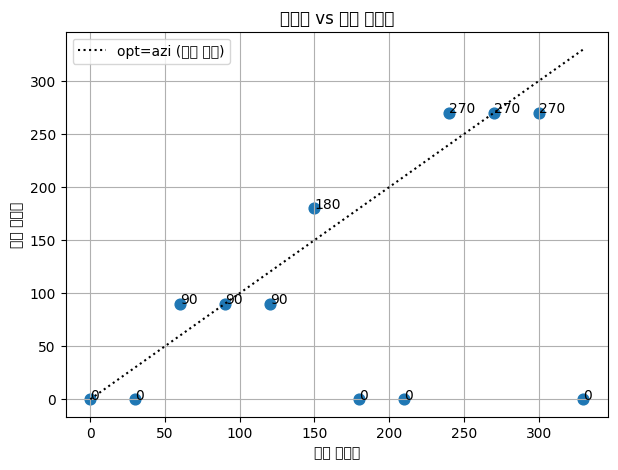

In [ ]:
# === Test A-2: 여러 방위각에서 최적 회전각 → 보정식 도출 (HH 고정) ===
import numpy as np, matplotlib.pyplot as plt

ANG_STEP = 30
hh = sorted([m for m in meta if m["pol"] == "HH"], key=lambda m: m["azi"])
angles = list(range(0, 360, ANG_STEP))

opt_azi, opt_ang = [], []
print(f"{'azi':>4} | {'best각':>6} | {'best recall':>11}")
for m in hh:
    sc = load_dom_rgb(m["path"]); gt = load_gt(m["path"])
    rs = [eval_at_angle(sc, gt, a)[0] for a in angles]
    bi = int(np.argmax(rs))
    opt_azi.append(m["azi"]); opt_ang.append(angles[bi])
    print(f"{m['azi']:>4} | {angles[bi]:>5}° | {rs[bi]*100:>9.1f}%")

opt_azi, opt_ang = np.array(opt_azi), np.array(opt_ang)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(opt_azi, opt_ang, s=60)
for x, y in zip(opt_azi, opt_ang): ax.annotate(f"{y}", (x, y))
ax.plot([0, 330], [0, 330], "k:", label="opt=azi (현재 가정)")
ax.set_xlabel("장면 방위각"); ax.set_ylabel("최적 회전각")
ax.set_title("방위각 vs 최적 회전각"); ax.legend(); ax.grid(True); plt.show()

## 6. Test B — 48개 (방위각 × 편파) 표  ← 가설 2 검증
각 파일에 **현재 방식(방위각 기반 ±회전 중 recall 최고)** 을 적용해 recall/E2E/분류를 측정하고,
방위각(행) × 편파(열) 표로 본다. badness가 방위각을 따라가는지, 편파를 따라가는지 드러난다.

⚠ 48장 전부면 T4에서 ~15분+. 빠르게 보려면 `EVAL_IDXS`를 일부만 지정.

In [ ]:
import pandas as pd

# ▼ 평가 대상. None이면 전체 48장. 예: 한 편파만 보려면 [i for i,m in enumerate(meta) if m['pol']=='HH']
EVAL_IDXS = None
CONF = 0.5
# ──────────────────────────────────

idxs = EVAL_IDXS if EVAL_IDXS is not None else list(range(len(meta)))

# === 보정식 v2: 회전=방위각 가장 가까운 90°, 180° 모호성은 E2E로 결정 ===
def correct_by_azimuth(scene_rgb, gt, azi):
    base = int(round(azi / 90.0) * 90) % 360
    cands = sorted({base, (base + 180) % 360})
    best = None   # 선택 기준 = E2E(recall*cls) — 분류까지 맞는 방향
    for a in cands:
        r, c, nb = eval_at_angle(scene_rgb, gt, a, CONF)
        score = r * c
        if best is None or score > best[0]:
            best = (score, a, r, c, nb)
    _, a, r, c, nb = best
    return (a, r, c, nb)

rows = []
for k, i in enumerate(idxs):
    m = meta[i]
    sc = load_dom_rgb(m["path"]); gt = load_gt(m["path"])
    a, r, c, nb = correct_by_azimuth(sc, gt, m["azi"])
    rows.append({"idx": i, "azi": m["azi"], "pol": m["pol"], "n_gt": len(gt),
                 "rot": a, "recall": round(r, 3), "cls_on_det": round(c, 3),
                 "E2E": round(r * c, 3)})
    print(f"[{k+1}/{len(idxs)}] {m['folder']:<20} {m['pol']:>3} | "
          f"rot={a:>3} recall={r*100:4.0f}% cls={c*100:4.0f}% E2E={r*c*100:4.0f}%")

df = pd.DataFrame(rows)
print("\n=== 방위각 × 편파: recall ===")
print(df.pivot_table(index="azi", columns="pol", values="recall"))
print("\n=== 방위각 × 편파: E2E ===")
print(df.pivot_table(index="azi", columns="pol", values="E2E"))
df.to_csv(f"{SAVE_DIR}/results/dom_diag_table_after.csv", index=False)
print("\n표 저장:", f"{SAVE_DIR}/results/dom_diag_table_after.csv")

[1/48] 30deg_0azi_ID1        HH | rot=  0 recall=  95% cls=  82% E2E=  77%
[2/48] 30deg_0azi_ID1        HV | rot=  0 recall=  95% cls=  84% E2E=  80%
[3/48] 30deg_0azi_ID1        VH | rot=  0 recall=  95% cls=  82% E2E=  77%
[4/48] 30deg_0azi_ID1        VV | rot=  0 recall=  92% cls=  76% E2E=  70%
[5/48] 30deg_120azi_ID3      HH | rot= 90 recall=  70% cls=  46% E2E=  32%
[6/48] 30deg_120azi_ID3      HV | rot= 90 recall=  65% cls=  38% E2E=  25%
[7/48] 30deg_120azi_ID3      VH | rot= 90 recall=  72% cls=  38% E2E=  27%
[8/48] 30deg_120azi_ID3      VV | rot= 90 recall=  60% cls=  50% E2E=  30%
[9/48] 30deg_150azi_ID9      HH | rot=180 recall=  90% cls=  58% E2E=  52%
[10/48] 30deg_150azi_ID9      HV | rot=180 recall=  90% cls=  47% E2E=  42%
[11/48] 30deg_150azi_ID9      VH | rot=180 recall=  85% cls=  50% E2E=  42%
[12/48] 30deg_150azi_ID9      VV | rot=180 recall=  75% cls=  37% E2E=  27%
[13/48] 30deg_180azi_ID4      HH | rot=180 recall=  95% cls=  68% E2E=  65%
[14/48] 30deg_180azi_

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54200 (\N{HANGUL SYLLABLE PYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


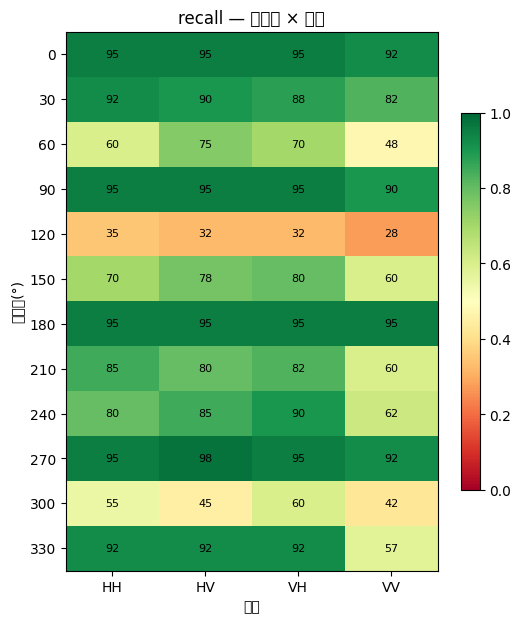

In [ ]:
# 히트맵 (recall): 행=방위각, 열=편파
import matplotlib.pyplot as plt
piv = df.pivot_table(index="azi", columns="pol", values="recall")
fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(piv.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
ax.set_xlabel("편파"); ax.set_ylabel("방위각(°)"); ax.set_title("recall — 방위각 × 편파")
for r in range(piv.shape[0]):
    for c in range(piv.shape[1]):
        v = piv.values[r, c]
        if not np.isnan(v):
            ax.text(c, r, f"{v*100:.0f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.7); plt.show()

### Test B 해석 가이드
- **세로(방위각)로 색이 변하고 가로(편파)로는 비슷** → 방위각이 주범 (가설 1). Test A의 회전 교정이 답.
- **가로(편파)로 색이 변하고 세로로는 비슷** → 편파가 주범 (가설 2). cross-pol 약점.
- **0azi 행만 초록, 나머지 전부 빨강** → 현재 회전 보정이 비0°에서 사실상 작동 안 함을 확정.
  → Test A에서 찾은 올바른 각도(부호/오프셋)로 보정식을 고치면 회복 기대.

## 종합 결론 쓰는 법
1. Test A best 각도 vs 방위각 관계 → 회전 매핑이 맞는지/오프셋 있는지
2. Test B 히트맵 → 방위각 축 vs 편파 축 중 무엇이 지배적인지
3. 둘을 합쳐: (a) 회전식 오프셋 교정으로 비0° 방위각 회복 가능한지, (b) cross-pol은 별도 한계인지